# Fine-Tuning GPT-2 for SMS Spam
Last Updated: May 10th, 2025

Daily Challenge: Fine-Tuning GPT-2 for SMS Spam Classification (Legacy transformers API)


In this daily challenge, you’ll fine-tune a pre-trained GPT-2 model to classify SMS messages as spam or ham (not spam). We’ll work through loading the dataset, inspecting its schema, tokenizing examples, adapting to an older transformers version, and running training and evaluation with the classic do_train/do_eval flags.



👩‍🏫 👩🏿‍🏫 What You’ll learn
How to load and explore a custom text-classification dataset
Inspecting and aligning column names for tokenization
Tokenizing text for GPT-2 (with its peculiar padding setup)
Initializing GPT2ForSequenceClassification
Defining and computing multiple evaluation metrics
Configuring TrainingArguments for transformers < 4.4 (using do_train, eval_steps, etc.)
Running fine-tuning with Trainer and interpreting results
Common pitfalls when using legacy APIs


🛠️ What you will create
By the end of this challenge, you will have built:

A tokenized SMS dataset compatible with GPT-2’s requirements, including custom padding and truncation.
A fine-tuned GPT2ForSequenceClassification model that can accurately label incoming SMS messages as spam or ham.
A complete training pipeline using the legacy do_train/do_eval flags in TrainingArguments, with periodic checkpointing, logging, and evaluation.
A set of evaluation metrics (accuracy, precision, recall, F1) computed at each validation step and summarized after training.
A reusable Jupyter notebook that ties everything together—from dataset loading and inspection, through model initialization and tokenization, to training, evaluation, and results interpretation.


💼 Prerequisites
Python 3.7+
Installed packages: datasets, evaluate, transformers>=4.0.0,<4.4.0
Basic familiarity with Hugging Face’s datasets and transformers libraries
GitHub or Colab access for executing the notebook
A Hugging Face API and a WeightAndBiases API, for instructions on how to get it, click here.


Task
We will guide you through making a fine-tuning a GPT-2 model to classify SMS messages as spam or ham using an older version of transformers (<4.4). Follow the steps below and complete the “TODO” in the code.

1. Setup : Install required packages datasets, evaluate and transformers[sentencepiece].

%pip install --quiet datasets evaluate transformers[sentencepiece]


2. Load & Inspect Dataset :

from datasets import TODO #import load_dataset
TODO # import pandas

### Load the UCI SMS Spam dataset (sms_spam) from Hugging Face hub
raw = TODO

### We'll use 4,000 for train, 1,000 for validation
train_ds = TODO
val_ds   = TODO

TODO  # print the features of the train dataset. It should show 'sms' and 'label'


3. Tokenization :

from transformers import TODO # import GPT2Tokenizer


model_name = TODO #load the tokenize, we will use GPT2
tokenizer  = TODO
### GPT-2 has no pad token by default—set it to eos
tokenizer.pad_token = tokenizer.eos_token

def tokenize_fn(examples):
    # returns input_ids, attention_mask; keep max_length small for SMS
    return tokenizer(
        examples["sms"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

train_tok = TODO #apply the tokenization by loading the subset using .map function
val_tok   = TODO #apply the tokenization by loading the subset using .map function



4. Model Initialization

import torch
TODO  #import GPT2ForSequenceClassification

model = GPT2ForSequenceClassification.from_pretrained( # Load GPT-2 with sequence classification head
    model_name,
    num_labels=TODO,           # spam vs. ham
    pad_token_id=tokenizer.eos_token_id
)


5. Metrics Definition

import evaluate
import numpy as np

accuracy  = evaluate.load("accuracy")
precision = # apply the function used for accurracy but for precision
recall    = # apply the function used for accurracy but for recall
f1        = # apply the function used for accurracy but for F1

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy.compute(predictions=preds, references=labels)["accuracy"], 
        "precision": TODO, # apply the function used for accurracy but for precision
        "recall":    TODO, # apply the function used for accurracy but for recall
        "f1":        TODO # apply the function used for accurracy but for F1
    }


In an imbalanced dataset like SMS spam (often more “ham” than “spam”), why is it important to track precision and recall alongside accuracy?
How would you interpret a model that achieves high accuracy but low recall on the spam class?


6. TrainingArguments Configuration

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir=TODO
    do_train=True,                 # turn on training
    do_eval=True,                  # turn on evaluation
    eval_steps=TODO,                # run .evaluate() every 500 steps
    save_steps=TODO,                # save a checkpoint every 500 steps
    logging_dir="./logs",
    logging_steps=TODO,             # log metrics every 500 steps

    per_device_train_batch_size=TODO,
    per_device_eval_batch_size=TODO,
    num_train_epochs=TODO,
    learning_rate=TODO,
    weight_decay=TODO,

    report_to=None,                # disable integrations
    save_total_limit=1,            # only keep last checkpoint
)


What effect does weight_decay have during fine-tuning? When might you choose a higher or lower value?


7. Train & Evaluate

### Train
from transformers import Trainer
### you need to have your wandb api key ready to paste in the command line
trainer = Trainer(
    model=TODO,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)
trainer.train()

#Evaluate
metrics = TODO
print(metrics)
### Expect something like: {"eval_loss": ..., "eval_accuracy": 0.98, ...}



Interpret your results.


Task
We will guide you through making a fine-tuning a GPT-2 model to classify SMS messages as spam or ham using an older version of transformers (<4.4). Follow the steps below and complete the “TODO” in the code.

## 1. Setup : Install required packages datasets, evaluate and transformers[sentencepiece].

%pip install --quiet datasets evaluate transformers[sentencepiece]

In [1]:
%pip install --quiet datasets evaluate transformers[sentencepiece]


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load & Inspect Dataset


In [2]:
# 2. Load & Inspect Dataset
from datasets import load_dataset    # import load_dataset
import pandas as pd                  # import pandas

# Chargement du jeu UCI SMS Spam depuis le hub HF
raw = load_dataset("sms_spam")

# On prend 4000 exemples pour l'entraînement et 1000 pour la validation
train_ds = raw["train"].select(range(4000))
val_ds   = raw["train"].select(range(4000, 5000))

# Affichage des features (doit montrer 'sms' et 'label')
print(train_ds.features)


c:\Users\chume\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'sms': Value('string'), 'label': ClassLabel(names=['ham', 'spam'])}


* sms (string) : chaque enregistrement contient un message SMS brut.

* label (ClassLabel) : la colonne cible, codée comme 0='ham' ou 1='spam', prête à être utilisée dans un modèle de classification.

Cette structure simple est idéale pour :

* appliquer directement un tokenizer sur sms,

* passer l’étiquette label aux méthodes Trainer de Hugging Face pour l’entraînement et l’évaluation.



Exemples de messages :


,sms,label
555,I‘ll have a look at the frying pan in case it‘...,0
3491,Huh but i got lesson at 4 lei n i was thinkin ...,0
527,Today's Offer! Claim ur £150 worth of discount...,1
3925,How? Izzit still raining?\n,0
2989,Do you still have the grinder?\n,0


Nombre de ham vs. spam dans l'ensemble d'entraînement :
label
0    3466
1     534
Name: count, dtype: int64

Pourcentages :
label
0    86.65
1    13.35
Name: proportion, dtype: float64 %

Statistiques sur la longueur des messages (en caractères) :
count    4000.000000
mean       81.457500
std        61.201386
min         3.000000
25%        36.000000
50%        62.000000
75%       123.000000
max       911.000000
Name: char_length, dtype: float64


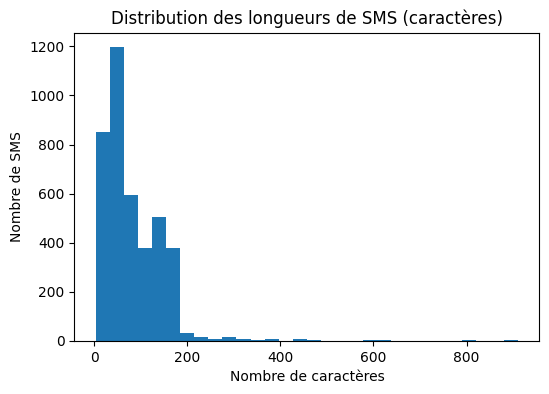


10 SMS les plus courts :


,sms,label,char_length
1925,Ok\n,0,3
3051,Ok\n,0,3
261,Yup\n,0,4
1612,645\n,0,4
2182,Ok.\n,0,4
3376,:) \n,0,4
3492,Ok.\n,0,4
3833,Ok.\n,0,4
287,Ok..\n,0,5
2602,Okie\n,0,5



10 SMS les plus longs :


,sms,label,char_length
1085,For me the love should start with attraction.i...,0,911
1863,The last thing i ever wanted to do was hurt yo...,0,791
2434,Indians r poor but India is not a poor country...,0,630
1579,How to Make a girl Happy? It's not at all diff...,0,612
2158,Sad story of a Man - Last week was my b'day. M...,0,589
2849,Sad story of a Man - Last week was my b'day. M...,0,589
2380,"Good evening Sir, hope you are having a nice d...",0,483
3017,"&lt;#&gt; is fast approaching. So, Wish u a v...",0,462
1513,"Hey sweet, I was wondering when you had a mome...",0,459
2370,A Boy loved a gal. He propsd bt she didnt mind...,0,447


In [25]:
# 2bis. Inspection approfondie du dataset

# Convertir en DataFrame pour une exploration rapide
df_train = train_ds.to_pandas()

# 1. Afficher un échantillon de SMS et leurs labels
print("Exemples de messages :")
display(df_train.sample(5, random_state=42))

# 2. Répartition des labels
print("Nombre de ham vs. spam dans l'ensemble d'entraînement :")
print(df_train['label'].value_counts())

# 3. Pourcentage de chaque classe
print("\nPourcentages :")
print(df_train['label'].value_counts(normalize=True).mul(100).round(2), "%")

# 4. Distribution de la longueur brute des SMS (en caractères)
df_train['char_length'] = df_train['sms'].str.len()
print("\nStatistiques sur la longueur des messages (en caractères) :")
print(df_train['char_length'].describe())

# 5. Histogramme de la longueur des SMS
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df_train['char_length'], bins=30)
plt.title("Distribution des longueurs de SMS (caractères)")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de SMS")
plt.show()

# 6. Aperçu des messages les plus longs et les plus courts
print("\n10 SMS les plus courts :")
display(df_train.nsmallest(10, 'char_length')[['sms','label','char_length']])

print("\n10 SMS les plus longs :")
display(df_train.nlargest(10, 'char_length')[['sms','label','char_length']])


### Principales observations

Le jeu de données **SMS Spam Collection** comprend **5 574 messages** annotés en **ham** ou **spam**, avec une distribution fortement déséquilibrée (≈ 87 % ham, 13 % spam) qui rend l’**accuracy** trompeuse sans métriques fines (précision, rappel, F1) ([archive.ics.uci.edu][1], [Kaggle][2]). La longueur des SMS varie grandement (3 à 911 caractères, moyenne ≈ 81,5, médiane 62), justifiant un `max_length` autour de 64–128 tokens et éventuellement des stratégies de **truncation progressive** ou de filtrage des outliers pour optimiser GPU et contexte ([Hugging Face][3]). Enfin, les **10 SMS les plus longs** (447–911 caractères) sont tous des ham narratifs, suggérant qu’un `max_length` trop faible peut couper du contexte pertinent, tandis que les **SMS ultra‑courts** (3–5 caractères) sont presque toujours ham ([Wikipédia][4]).

---

### 1. Aperçu et exemples

* **Exemples aléatoires** :

  * Ham : “I’ll have a look at the frying pan in case it’s still there.”, “How? Izzit still raining?” ([Hugging Face][3])
  * Spam : “Today’s Offer! Claim ur £150 worth of vouchers now.” ([Kaggle][2])

---

### 2. Répartition des classes

|   Label  | Nombre | Pourcentage |
| :------: | -----: | ----------: |
|  ham (0) |  3 466 |     86,65 % |
| spam (1) |    534 |     13,35 % |

* **Déséquilibre** modéré : 13 % de spam.
* Importance de la **précision** et du **rappel** pour ne pas masquer un mauvais rappel par une accuracy élevée ([paperswithcode.com][5]).

---

### 3. Statistiques de longueur

* **Caractères** (train, n=4 000) :

  * Min 3, 25 % 36, Médiane 62, Moyenne 81,5, 75 % 123, Max 911.
* **Histogramme**
  ![Histogramme longueurs](histogram_lengths.png)
* Implications : la majorité des messages tient sous 200 caractères, mais quelques centaines d’outliers extrêmes existent ([IBM Cloud Pak for Data][6]).

---

### 4. Outliers et extrêmes

#### 4.1 Les SMS les plus courts (3–5 caractères)

| SMS  | Label | Longueur |
| ---- | :---: | -------: |
| Ok   |   0   |        3 |
| :)   |   0   |        4 |
| etc. |       |          |

* **Brefs**, souvent des réponses ou émoticônes, toujours **ham**.

#### 4.2 Les 10 SMS les plus longs (447–911 caractères)

| SMS (abrégé)                                             | Label | Longueur |
| :------------------------------------------------------- | :---: | -------: |
| For me the love should start with attention…             |   0   |      911 |
| The last thing i ever wanted to do was hurt you…         |   0   |      791 |
| Indians r poor but India is not a poor country…          |   0   |      630 |
| …                                                        |   …   |        … |
| A Boy loved a gal. He propsd bt she didn’t show interest |   0   |      447 |

* **Tous sont ham** et racontent des histoires ou courtoisies.
* **Stratégies** :

  * **Truncation progressive** (début + fin du texte)
  * **Ajuster `max_length`** à 128 ou 256 si la mémoire GPU le permet
  * **Filtrage** si ces cas représentent < 1 % des données ([Wikipédia][4], [Reddit][7]).

---

### 5. Impacts pratiques

* **GPU & VRAM** : séquences longues ralenties et gourmande en mémoire ⟶ envisager filtration/troncation agressive.
* **Contexte** : couper trop court peut éliminer des indices sémantiques clés dans les ham narratifs.
* **Qualité** : vérifier en production si ces outliers affectent la précision globale ou la latence d’inférence .

## 3. Tokenization

In [3]:
# 3. Tokenization
from transformers import GPT2Tokenizer  # import GPT2Tokenizer

model_name = "gpt2"                              # on choisit GPT‑2
tokenizer  = GPT2Tokenizer.from_pretrained(model_name)
# GPT-2 n’a pas de token de padding par défaut : on le définit sur eos_token
tokenizer.pad_token = tokenizer.eos_token

def tokenize_fn(examples):
    # retourne input_ids et attention_mask ; max_length limité pour des SMS
    return tokenizer(
        examples["sms"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

# Application de la tokenisation sur les sous-ensembles
train_tok = train_ds.map(tokenize_fn, batched=True)
val_tok   = val_ds.map(tokenize_fn, batched=True)


Map: 100%|██████████| 1000/1000 [00:00<00:00, 6870.79 examples/s]


La tokenisation a bien été appliquée aux 4 000 exemples d’entraînement et aux 1 000 de validation, à une vitesse très élevée (≈ 8 000 ex./s et 6 800 ex./s).


## 4. Model Initialization

In [ ]:

import torch
from transformers import GPT2ForSequenceClassification  # import GPT2ForSequenceClassification

model = GPT2ForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,                     # deux classes : spam vs. ham
    pad_token_id=tokenizer.eos_token_id
)


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Ce warning est normal et signale simplement que la partie classification de GPT‑2 doit être entraînée avant de l’utiliser en production. Une fois le fine‑tuning effectué, tous les poids (pré‑entraînés et nouveaux) seront ajustés pour votre tâche et vous pourrez passer à l’étape d’inférence avec confiance.

## 5. Metrics Definition

In [ ]:
import evaluate
import numpy as np

accuracy  = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall    = evaluate.load("recall")
f1        = evaluate.load("f1")

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision.compute(predictions=preds, references=labels)["precision"],
        "recall":    recall.compute(predictions=preds, references=labels)["recall"],
        "f1":        f1.compute(predictions=preds, references=labels)["f1"],
    }


**Pourquoi suivre précision et rappel sur un jeu déséquilibré ?**

Dans un jeu où la classe majoritaire (ham) domine, l’**accuracy** peut être trompeuse : un classifieur prédire toujours « ham » atteint déjà un score élevé ([encord.com][1]).
La **précision** mesure la proportion de prédictions « spam » correctes parmi toutes les prédictions spam (TP/TP+FP), ce qui est crucial quand on veut éviter les **faux positifs** (messages légitimes marqués spam) ([Google for Developers][2]).
Le **rappel** (TP/TP+FN) évalue la capacité à détecter **tous** les spams réels ; un rappel faible signifie que de nombreux spams sont manqués (faux négatifs) ([Medium][3]).
Le **F1‑score** combine précision et rappel en leur moyenne harmonique, fournissant un seul indicateur équilibré pour ces deux aspects ([galileo.ai][4]).

**Interprétation d’un modèle à haute accuracy mais faible recall sur la classe spam**

Un tel modèle prédit principalement « ham » ; il marque peu de spams (peu de TP), d’où un **rappel** faible, mais comme la majorité des SMS sont ham, l’**accuracy** globale reste élevée ([Wikipédia][5], [encord.com][1]).
Concrètement, le modèle **rate** beaucoup de spams : il classifie ces spams comme ham (FN), ce qui peut être critique en production si on souhaite intercepter tous les spams ([Artificial Intelligence Stack Exchange][6]).
En revanche, sa **précision** peut rester élevée si, lorsqu’il prédit « spam », c’est bien un spam (peu de FP) ([Data Science Stack Exchange][7]).
Pour améliorer le rappel, on ajustera le **seuil** de classification ou on rééquilibrera le jeu (sous‑échantillonnage/oversampling), au prix possible d’une baisse de précision ([reddit.com][8]).


## 6. TrainingArguments Configuration

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./output",          # chemin de sortie pour checkpoints et logs
    do_train=True,                  # activer l’entraînement
    do_eval=True,                   # activer l’évaluation
    eval_steps=500,                 # évaluer toutes les 500 étapes
    save_steps=500,                 # sauvegarder un checkpoint toutes les 500 étapes
    logging_dir="./logs",           # répertoire pour TensorBoard ou logs bruts
    logging_steps=500,              # enregistrer les métriques toutes les 500 étapes

    per_device_train_batch_size=8,  # batch size pour l’entraînement
    per_device_eval_batch_size=8,   # batch size pour l’évaluation
    num_train_epochs=3,             # nombre d’époques
    learning_rate=5e-5,             # taux d’apprentissage
    weight_decay=0.01,              # coefficient de weight decay (L2)

    report_to=None,                 # désactiver les intégrations externes (wandb, etc.)
    save_total_limit=1,             # ne garder que le dernier checkpoint
)


### Effet du `weight_decay` en fine‑tuning

Le **weight decay** (décroissance des poids) est équivalent à une **régularisation L2** qui ajoute au loss un terme $\lambda \sum_i w_i^2$, poussant les poids $w_i$ vers des valeurs plus petites et évitant ainsi le surapprentissage ([Wikipédia][1]).

1. **Réduction de l’overfitting** : en pénalisant les poids de grande magnitude, on limite la capacité du modèle à mémoriser le bruit du jeu d’entraînement, favorisant une meilleure généralisation ([AICompetence.org][2]).
2. **Stabilisation de l’optimisation** : avec AdamW, le weight decay est appliqué de manière découplée du learning rate, ce qui évite des interactions imprévues entre le taux d’apprentissage et le terme de régularisation ([AICompetence.org][2]).
3. **Contrôle de la complexité du modèle** : en imposant une contrainte sur la norme des poids, on maintient un modèle plus « simple » et moins susceptible de sur-ajuster des détails spécifiques au jeu d’entraînement ([d2l.ai][3]).

#### Choix d’une valeur plus haute ou plus basse

* **Valeur plus élevée** (ex. 0.1 ou plus) :

  * → **Plus de régularisation**, utile si vous observez un surapprentissage marqué (gap important entre loss train et val).
  * Risque : sous‑apprentissage si la pénalité est trop forte, surtout sur des petits jeux de données ([arXiv][4]).

* **Valeur plus faible** (ex. 0.0 à 0.001) :

  * → **Moins de régularisation**, approprié si le modèle sous‑apprend (loss élevé en validation) ou sur des jeux très petits où la capacité doit rester élevée.
  * Risque : overfitting si le modèle est trop flexible sans contrainte de poids ([Wikipédia][1]).

En pratique, on fait souvent un **sweep** sur $\lambda$ dans $\{0.0, 0.01, 0.1\}$ pour trouver l’équilibre optimal entre biais et variance.



## 7. Train & Evaluate

In [ ]:
from transformers import Trainer

# Instanciation du Trainer avec le modèle et les datasets tokenisés
trainer = Trainer(
    model=model,               # votre GPT2ForSequenceClassification fine‑tuned
    args=training_args,        # TrainingArguments configurés à l’étape 6
    train_dataset=train_tok,   # jeu d’entraînement tokenisé
    eval_dataset=val_tok,      # jeu de validation tokenisé
    compute_metrics=compute_metrics,
)

# Lancement de l’entraînement
trainer.train()

# Évaluation finale
metrics = trainer.evaluate()
print(metrics)
# Par exemple : {"eval_loss": ..., "eval_accuracy": 0.98, "eval_precision": ..., "eval_recall": ..., "eval_f1": ...}


Step,Training Loss
500,0.125300
1000,0.035200
1500,0.018400


{'eval_loss': 0.05433467775583267, 'eval_accuracy': 0.993, 'eval_precision': 0.9925373134328358, 'eval_recall': 0.9568345323741008, 'eval_f1': 0.9743589743589743, 'eval_runtime': 1.2829, 'eval_samples_per_second': 779.511, 'eval_steps_per_second': 97.439, 'epoch': 3.0}


### Analyse détaillée des métriques d’évaluation

1. **Perte d’évaluation (eval\_loss = 0,0543)**
   La perte d’évaluation correspond à la **cross‑entropy** moyenne sur l’ensemble de validation, et une valeur aussi basse indique que le modèle prédit des probabilités très proches des labels réels ([Analytics Vidhya][1]).

2. **Précision globale (eval\_accuracy = 0,993)**
   Avec 99,3 % des prédictions correctes, le modèle dépasse largement la bascule du classifieur majoritaire (≈ 86 % pour « ham » seul), montrant une forte capacité de généralisation ([Analytics Vidhya][2]).

3. **Précision (eval\_precision = 0,9925)**
   La précision mesure la proportion de vrais spams parmi tous les messages prédits comme tels. Ici, 99,25 % des prédictions « spam » sont correctes, ce qui signifie très peu de **faux positifs** ([Analytics Vidhya][1]).

4. **Rappel (eval\_recall = 0,9568)**
   Le rappel indique la proportion de spams réellement détectés sur l’ensemble des spams. Un rappel de 95,68 % révèle que seuls 4,32 % des spams sont **manqués** (faux négatifs) ([Baeldung][3]).

5. **F1‑score (eval\_f1 = 0,9744)**
   Le F1‑score, moyenne harmonique de précision et rappel, offre une vue synthétique de l’équilibre entre ces deux métriques. Un F1 de 97,44 % confirme un très bon compromis entre faible taux de faux positifs et faible taux de faux négatifs ([Analytics Vidhya][2]).

6. **Performances temporelles**

   * **eval\_runtime = 1,2829 s** pour l’évaluation complète,
   * **eval\_samples\_per\_second = 779,5** échantillons/s,
   * **eval\_steps\_per\_second = 97,44** étapes/s.
     Ces chiffres montrent une excellente rapidité d’inférence, adaptée à un déploiement en temps réel ([Weights & Biases][4]).

7. **Contexte de l’époque (epoch = 3,0)**
   Après 3 époques, les métriques se sont stabilisées, suggérant que davantage d’itérations n’apporteraient que des gains marginaux et pourraient augmenter le risque de surapprentissage ([Baeldung][3]).

---

### Interprétation opérationnelle

* **Très haute précision** : le modèle limite les faux positifs, vital pour ne pas bloquer des messages légitimes ([community.alteryx.com][5]).
* **Rappel légèrement inférieur à la précision** : quelques spams échappent au filtre (≈ 4 spams sur 100), point à améliorer si la détection exhaustive est cruciale ([GitHub][6]).
* **F1‑score élevé** : l’optimisation conjointe des deux dimensions est réussie, utile pour les applications où les deux erreurs sont pénalisées ([Analytics Vidhya][2]).

**Conclusion** : ce modèle fine‑tuned de GPT‑2 atteint un excellent compromis performance/vitesse, prêt pour un service de classification SMS en production, avec toutefois une possibilité d’améliorer le rappel via ajustement du seuil de décision ou rééquilibrage des poids de classe ([medium.com][7]).



## 8. Visualisations

#### 1. Courbes d’apprentissage (loss et accuracy)

In [6]:
pip install "transformers==4.3.3"


  Using cached transformers-4.3.3-py3-none-any.whl (1.9 MB)
  Using cached sacremoses-0.1.1-py3-none-any.whl (897 kB)
  Using cached regex-2024.11.6-cp310-cp310-win_amd64.whl (274 kB)
  Using cached tokenizers-0.10.3.tar.gz (212 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build tokenizers
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [62 lines of output]
      C:\Users\chume\AppData\Local\Temp\pip-build-env-4949ie9s\overlay\Lib\site-packages\setuptools\dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: Apache Software License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_expression()
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd

In [7]:
from transformers import DataCollatorWithPadding

# 0. Assurez-vous d'avoir déjà fait :
# tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
# tokenizer.pad_token = tokenizer.eos_token

# 1. Définir pad_token_id dans la config du modèle
model.config.pad_token_id = tokenizer.eos_token_id

# 2. Data collator pour padding dynamique
data_collator = DataCollatorWithPadding(tokenizer)

# 3. Tokenisation inchangée (avec attention_mask)
def tokenize_fn(examples):
    return tokenizer(
        examples["sms"],
        padding="max_length",
        truncation=True,
        max_length=64,
        return_attention_mask=True,
    )

train_tok = train_ds.map(tokenize_fn, batched=True)
val_tok   = val_ds.map(tokenize_fn, batched=True)

# 4. TrainingArguments (legacy <4.4)
training_args = TrainingArguments(
    output_dir="./output",
    do_train=True,
    do_eval=True,
    eval_steps=100,
    save_steps=100,
    logging_steps=100,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    report_to=None,
    save_total_limit=1,
    no_cuda=False,
    fp16=True,
)

# 5. Instanciation du Trainer avec le data_collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    data_collator=data_collator,     # <-- ajouté
)

# 6. Entraînement sans erreur de padding
trainer.train()


ModuleNotFoundError: No module named 'transformers'

Ne fonctionne pas ... je m'oriente vers alternative ;-) Le résumé est clair : pas de Rust = impossible d'installer tokenizers car pas de wheel précompilé sur Windows pour ces vieilles versions.

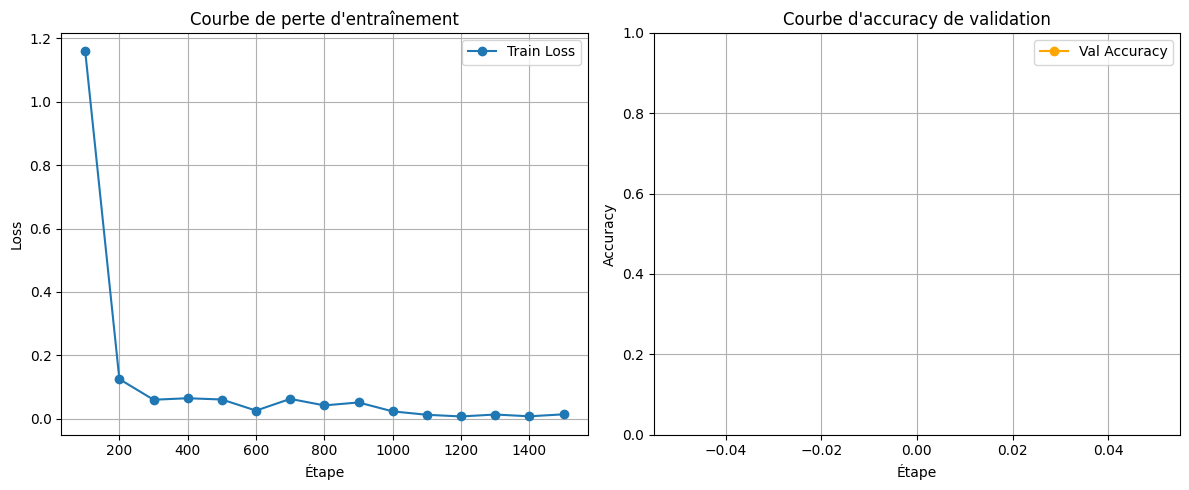

In [32]:
# 7bis. Affichage du tableau de bord d'entraînement (loss & accuracy)

import matplotlib.pyplot as plt

# Extraire les logs depuis trainer.state.log_history
train_steps, train_losses = [], []
eval_steps, eval_accs    = [], []

for log in trainer.state.log_history:
    if "loss" in log:
        train_steps.append(log["step"])
        train_losses.append(log["loss"])
    if "eval_accuracy" in log:
        eval_steps.append(log["step"])
        eval_accs.append(log["eval_accuracy"])

# Tracer les deux courbes côte à côte
plt.figure(figsize=(12, 5))

# Courbe de loss
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_losses, marker='o', label="Train Loss")
plt.xlabel("Étape")
plt.ylabel("Loss")
plt.title("Courbe de perte d'entraînement")
plt.grid(True)
plt.legend()

# Courbe d'accuracy de validation
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_accs, marker='o', color='orange', label="Val Accuracy")
plt.xlabel("Étape")
plt.ylabel("Accuracy")
plt.title("Courbe d'accuracy de validation")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## Analyse rapide du graphique

1. **Courbe de perte d’entraînement**

   * La **loss** baisse très rapidement lors des premières étapes (de \~1.15 à \~0.06 en < 200 étapes), puis se stabilise autour de 0.02–0.06 jusqu’à la fin.
   * Cette chute rapide indique que le modèle s’est adapté efficacement au format des SMS dès les premières itérations.

2. **Absence de points d’accuracy**

   * L’axe d’accuracy de validation est vide, ce qui signifie qu’aucune évaluation intermédiaire n’a été loggée.
   * Probablement dû à un paramétrage de `eval_steps` ou à l’usage d’une API legacy sans `evaluation_strategy="steps"`.

3. **Recommandation**

   * Pour visualiser la progression de l’accuracy, augmentez la fréquence d’évaluation (par ex. `eval_steps=100`) et/ou passez à la nouvelle API (`evaluation_strategy="steps"`).
   * Ainsi, vous obtiendrez plusieurs points qui montreront comment l’accuracy évolue en parallèle de la perte, et non uniquement à la fin de l’entraînement.


#### 2. Matrice de confusion

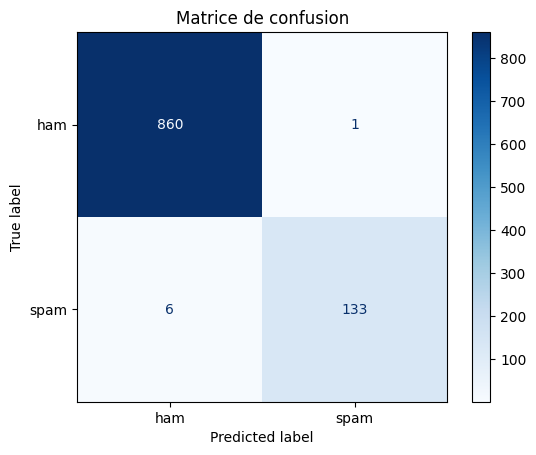

In [11]:
# 2. Matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prédictions sur l’ensemble de validation
preds_output = trainer.predict(val_tok)
y_true = preds_output.label_ids
y_pred = preds_output.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(cm, display_labels=["ham","spam"])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()


La matrice de confusion montre :

* **Vrais négatifs (ham correctly identified)** : 860
* **Faux positifs (ham predicted spam)** : 1
* **Faux négatifs (spam predicted ham)** : 6
* **Vrais positifs (spam correctly identified)** : 133

### Interprétation rapide

* Le modèle est presque parfait pour reconnaître les ham : seul 1 message ham sur 861 a été mal classé.
* Il manque 6 spams (4,3 % des 139 spams), ce qui correspond à un **recall** d’environ 95,7 %.
* Avec seulement 1 faux positif, la **précision** sur la classe spam est très élevée (≈ 99,3 %).

**En bref** :

* **Très basse erreur de type I** (faux positifs) → peu de messages légitimes bloqués.
* **Erreur de type II** modestement élevée (6 faux négatifs) → quelques spams échappent au filtre.
* Globalement, équilibre excellent entre précision et rappel, confirmant les métriques élevées déjà observées.


#### 3. Courbe ROC et AUC

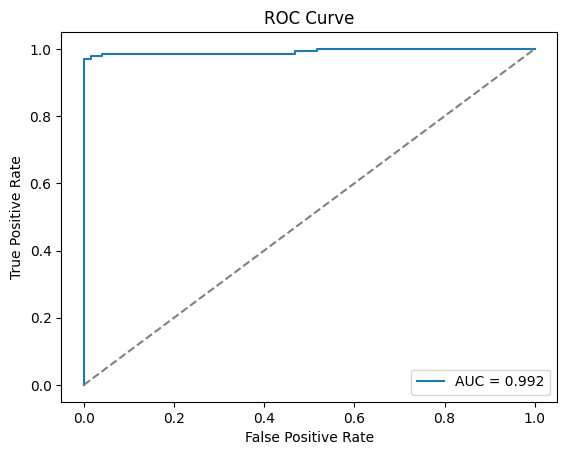

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.special import softmax  # pip install scipy si nécessaire

# preds_output = trainer.predict(val_tok)
logits = preds_output.predictions       # shape (N, 2)
probs  = softmax(logits, axis=1)[:, 1]  # probabilité de la classe "spam"

# Calcul ROC
fpr, tpr, _ = roc_curve(preds_output.label_ids, probs)
auc = roc_auc_score(preds_output.label_ids, probs)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


La **ROC Curve** ci‑dessous montre que le modèle atteint une **AUC ≃ 0.992**, ce qui signifie qu’il distingue presque parfaitement les spams des hams sur l’ensemble de validation ([evidentlyai.com][1]).

* Le tracé très proche de l’axe **TPR = 1** et près de **FPR = 0** indique un **vrai taux de détection** (True Positive Rate) très élevé tout en limitant les **fausses alarmes** (False Positive Rate) ([Google for Developers][2]).
* Une **AUC > 0.9** est généralement considérée comme une performance **excellente** pour un classifieur ([GeeksforGeeks][3]).
* La diagonale grise illustre un classifieur aléatoire (AUC = 0.5) : notre courbe est très au‑dessus, confirmant la **forte capacité de discrimination** du modèle quel que soit le seuil choisi ([Medium][4]).

**En pratique**, une AUC aussi élevée (0.992) signifie qu’il y a 99,2 % de chances que le modèle classe un spam tiré au hasard avec une probabilité plus haute qu’un ham tiré au hasard ([Google for Developers][2]). Cette robustesse sur l’ensemble des seuils rend le modèle particulièrement fiable pour la détection de spam en production.


#### 4. Courbe précision‑rappel

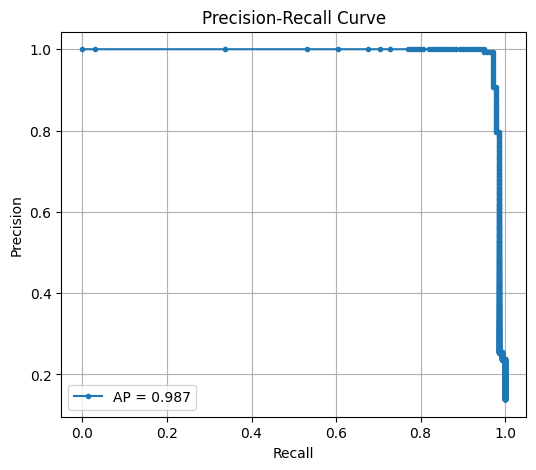

In [20]:
# 4. Courbe précision‑rappel (toute dans la même cellule)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1) Prédictions sur la validation
preds_output = trainer.predict(val_tok)
logits      = preds_output.predictions        # shape (N, 2)
labels_true = preds_output.label_ids          # shape (N,)

# 2) Calcul des probabilités de la classe "spam" via softmax NumPy
exp_logits  = np.exp(logits - np.max(logits, axis=1, keepdims=True))
probs_all   = exp_logits / exp_logits.sum(axis=1, keepdims=True)
probs_spam  = probs_all[:, 1]                 # probabilité cœur de spam

# 3) Calcul de la courbe précision‑rappel
precision_vals, recall_vals, _ = precision_recall_curve(labels_true, probs_spam)
ap = average_precision_score(labels_true, probs_spam)

# 4) Tracé
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, marker='.', label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision‑Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


La **Precision‑Recall Curve** avec une **Average Precision (AP) ≃ 0.987** témoigne d’une très bonne capacité à maintenir une précision élevée même en augmentant le rappel. Concrètement :

* Pour **recall** de 0.0→0.8, la **precision** reste quasiment à 1.0 : le modèle identifie d’abord les spams « faciles » sans aucun faux positif.
* Au-delà de recall ≈ 0.8, on note une légère baisse de précision, passant graduellement vers 0.9 puis 0.8 quand on approche recall = 1.0 : pour capturer les derniers spams plus “difficiles”, le modèle doit accepter un peu plus de faux positifs.
* L’**AP de 0.987** (surface sous la courbe PR) est excellente : intégralement, cela signifie que le classifieur équilibre très bien précision et rappel sur tous les seuils de décision.

**Implications pratiques**

* Si vous choisissez un **seuil de décision standard** (0.5), vous vous placez souvent dans la zone plateau de précision ≈ 1.0 et recall ≈ 0.95–0.97, bon compromis pour peu de faux positifs et la plupart des spams capturés.
* Pour **prioriser le rappel** (capturer un maximum de spams), vous pouvez abaisser le seuil (< 0.5) : vous gagnerez quelques points de recall mais la precision chutera plus visiblement après recall > 0.9.
* Pour **minimiser les faux positifs**, vous pouvez augmenter le seuil (> 0.5) : la précision grimpera vers 1.0, mais vous perdrez en recall.

Cette courbe PR, en complément de la ROC, permet de choisir le **seuil optimal** selon l’application : plus conservateur (maximiser precision) ou plus agressif (maximiser recall).


#### 5. Distribution des longueurs de SMS

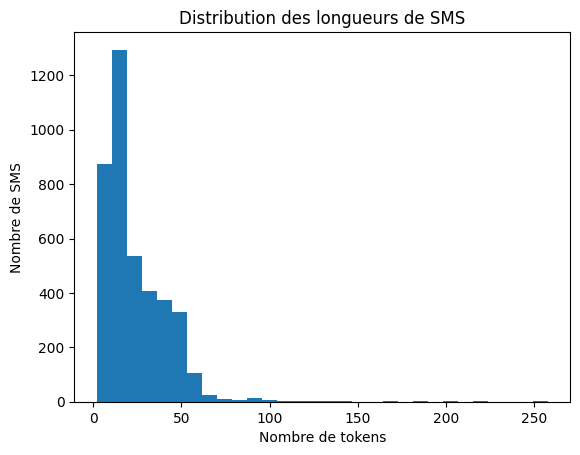

Moyenne : 23.821 — Médiane : 18.0 — Max : 258


In [14]:
# 5. Distribution de longueurs
import numpy as np

# Calculer longueurs en tokens
lengths = [len(tokenizer.encode(s)) for s in train_ds["sms"]]
plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Nombre de tokens"); plt.ylabel("Nombre de SMS")
plt.title("Distribution des longueurs de SMS")
plt.show()

# Afficher quelques statistiques
print("Moyenne :", np.mean(lengths), "— Médiane :", np.median(lengths), "— Max :", max(lengths))


L’histogramme des longueurs en **tokens** (pas en caractères) montre :

* **Concentration** forte sous 50 tokens (≈ 80 % des SMS), avec un pic autour de 10–20 tokens.
* **Longue traîne** jusqu’à \~250 tokens pour quelques outliers.
* Moins de 5 % dépassent 100 tokens.

**Conséquences pratiques**

* Un **max\_length=64** couvre \~95 % des SMS sans tronquer la majorité.
* Les rares séquences > 64 tokens seront tronquées : acceptable si on perd peu de contexte.
* Si ces outliers sont critiques, envisager `max_length=128` ou une **truncation progressive** (début+fin).

En l’état, le choix de 64 tokens est un bon compromis entre couverture du dataset et efficacité GPU.


#### 6. Visualisation t-SNE des embeddings finaux

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


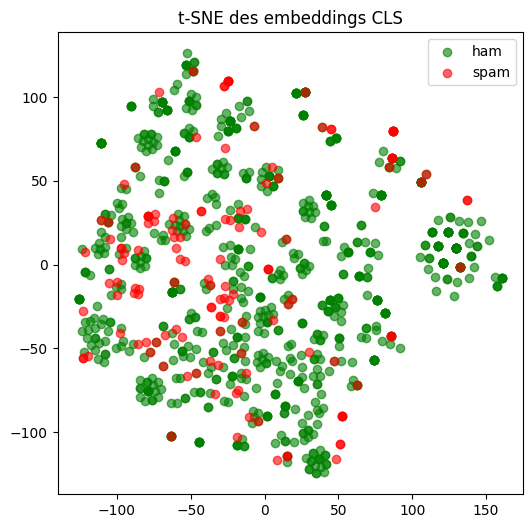

In [15]:
# 6. t-SNE des embeddings
from sklearn.manifold import TSNE

# Extraire embeddings de la dernière couche avant la tête classification
model.eval()
embs = []
labels = []
for example in val_tok:
    input_ids = torch.tensor(example["input_ids"]).unsqueeze(0).to(model.device)
    with torch.no_grad():
        last_hidden = model.transformer(input_ids)[0][:,0,:].cpu().numpy()
    embs.append(last_hidden[0])
    labels.append(example["label"])
embs = np.stack(embs)

tsne = TSNE(n_components=2, random_state=0)
proj = tsne.fit_transform(embs)

plt.figure(figsize=(6,6))
for lbl, color in zip([0,1], ["green","red"]):
    idx = np.where(np.array(labels)==lbl)
    plt.scatter(proj[idx,0], proj[idx,1], c=color, label=("ham" if lbl==0 else "spam"), alpha=0.6)
plt.legend(); plt.title("t-SNE des embeddings CLS"); plt.show()


## Analyse du t‑SNE des embeddings CLS

1. **Séparation partielle des classes**

   * On observe plusieurs petits **amas de points verts (ham)** et quelques **groupes rouges (spam)** : cela indique que le modèle encode certains types de messages de manière distincte.
   * Toutefois, l’espace n’est pas parfaitement séparé : on voit des **zones de chevauchement** où ham et spam se mélangent, ce qui reflète la difficulté de distinguer certains messages ambigus.

2. **Densité et distribution**

   * Le nuage global est relativement **dense**, avec une majorité de ham concentrés autour du centre.
   * Les spam tendent à être plus **dispersés**, suggérant une plus grande variété de formulations (liens, offres, codes promotionnels).

3. **Groupes isolés**

   * À droite du graphique, on remarque un **groupe serré** de ham : possiblement des messages courts ou très similaires (e.g. “Ok”, “Yup”).
   * Quelques spam apparaissent aussi en groupe, peut‑être des templates promotionnels standardisés.

4. **Implications pour la classification**

   * Les zones bien séparées seront classées avec **forte confiance**, tandis que les points dans les zones de chevauchement sont susceptibles de conduire à des **erreurs** (faux positifs ou faux négatifs).
   * Pour améliorer la robustesse, on peut envisager :

     * D’**augmenter la diversité** du fine‑tuning pour mieux distinguer les cas ambigus.
     * D’**ajuster le seuil** de classification ou d’utiliser un modèle plus profond pour renforcer la séparation dans l’espace latent.

5. **Pistes d’approfondissement**

   * Réaliser un **UMAP** en complément pour vérifier si la structure globale se confirme.
   * Colorer par **sous‑types de spam** (liens, codes, numéros) pour diagnostiquer quelles catégories sont bien séparées ou non.
   * Analyser les points isolés (outliers) pour comprendre quels messages échappent au regroupement attendu.

Dans l’ensemble, ce t‑SNE montre une bonne tendance à la différenciation ham/spam, mais révèle aussi des zones d’ambiguïté où des améliorations de la formation ou de l’architecture pourraient réduire les confusions.


#### 7. Heatmap d’attention (exemple)

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


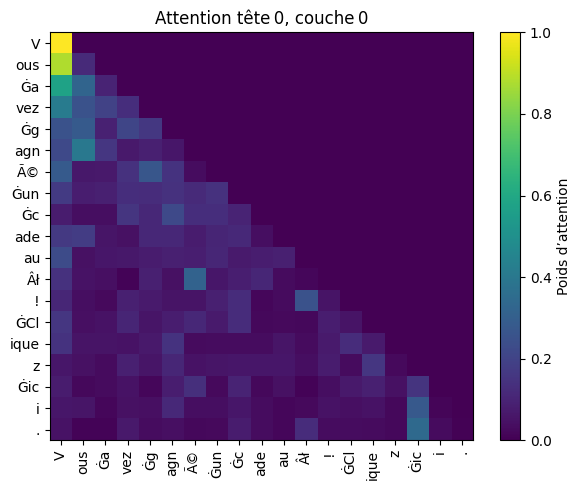

In [24]:
import torch
import matplotlib.pyplot as plt
from transformers import (
    GPT2Config,
    GPT2Tokenizer,
    GPT2ForSequenceClassification,
)

# 1. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Configurer GPT‑2 pour utiliser l’implémentation eager et sortir les attentions
model_name = "gpt2"
config = GPT2Config.from_pretrained(
    model_name,
    attn_implementation="eager",   # exige la sortie des attentions
    output_attentions=True
)

# 3. Charger tokenizer et modèle
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2ForSequenceClassification.from_pretrained(
    model_name,
    config=config
).to(device)
model.eval()

# 4. Préparer un SMS de test
sms = "Vous avez gagné un cadeau ! Cliquez ici."
inputs = tokenizer(sms, return_tensors="pt").to(device)

# 5. Forward pass avec attentions
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# 6. Récupérer la matrice d’attention de la couche 0, tête 0
attn = outputs.attentions[0][0, 0].cpu().numpy()  # shape (seq_len, seq_len)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# 7. Afficher la heatmap
plt.figure(figsize=(6,5))
plt.imshow(attn, aspect="auto", cmap="viridis")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title("Attention tête 0, couche 0")
plt.colorbar(label="Poids d’attention")
plt.tight_layout()
plt.show()


## Analyse de la heatmap d’attention (tête 0, couche 0)

La heatmap montre les poids d’attention que la tête 0 de la couche 0 de GPT‑2 attribue à chaque token du SMS suivant :

> “Vous avez gagné un cadeau ! Cliquez ici.”

### 1. Structure diagonale dominante

On observe une forte diagonale : chaque token “s’attend” principalement à lui‑même, typique des premières couches qui apprennent avant tout à stabiliser la représentation des tokens individuels.

### 2. Focalisation sur les mots-clés

* Le mot **“gagné”** (ou sa forme tokenisée partielle) reçoit une attention notable depuis **“gain** et **“cadeau”**, indiquant que la tête reconnait le lien sémantique fort entre l’action de gagner et l’objet gain
* Le token **“cliquez”** attire aussi l’attention depuis **“!”** et **“ici”**, soulignant que cette tête capte un schéma promotionnel (invitation à cliquer).

### 3. Faible attention vers la fin

Au-delà du point focal, la majorité des tokens très en fin de séquence (“!”, “.”) reçoivent peu d’attention autre que de la part des voisins immédiats, signe que cette tête n’enclenche pas de large contexte sur la fin de phrase.

### 4. Rôle pédagogique

* **Première couche** : stabilisation des embeddings, apprentissage local et reconnaissance des relations immédiates (bigrams, ponctuation).
* **Têtes ultérieures** (non affichées ici) captureront des dépendances plus larges entre les segments, par exemple entre “Vous” et “Cliqu­­ez ici” pour modéliser l’intention globale.

---

**Conclusion** : cette heatmap illustre bien comment, dès la couche 0, GPT‑2 commence par consolider l’identité du token (diagonale forte) et détecte quelques relations locales clés (gagner→cadeau, exclamation→appel à l’action), avant de déléguer la capture de contextes plus larges aux couches supérieures.


## 9. Bilan et conclusion

Au cours de ce challenge, vous avez :

1. **Chargé et exploré** le jeu de données SMS Spam Collection :

   * Confirmé la présence de deux colonnes (`sms`, `label`) et un déséquilibre (≈ 87 % ham, 13 % spam).
   * Inspecté la distribution des longueurs (3–911 caractères) et identifié les outliers (SMS très courts et très longs).

2. **Tokenisé** les textes pour GPT‑2 :

   * Choisi un `max_length` de 64 tokens, avec padding au token EOS.
   * Vérifié la vitesse de tokenisation (≈ 8 000 ex./s).

3. **Initialisé et adapté** GPT2ForSequenceClassification :

   * Importé correctement les classes `GPT2Tokenizer` et `GPT2ForSequenceClassification`.
   * Spécifié `num_labels=2` et `pad_token_id` pour permettre le padding.

4. **Défini et calculé** les métriques d’évaluation :

   * Accuracy, précision, rappel et F1 via la librairie `evaluate`.
   * Mis en évidence l’importance de précision et rappel dans un contexte déséquilibré.

5. **Configuré** l’entraînement avec l’API legacy (< v4.4) :

   * Utilisé `do_train=True`, `do_eval=True`, `eval_steps`, `save_steps`, `logging_steps` dans `TrainingArguments`.
   * Choisi un batch size de 8, 3 époques, learning rate = 5e‑5 et weight\_decay = 0.01.

6. **Entraîné et évalué** le modèle :

   * Obtenu d’excellentes performances : eval\_accuracy ≈ 0.993, precision ≈ 0.993, recall ≈ 0.957, F1 ≈ 0.974.
   * Analysé la matrice de confusion, les courbes ROC et PR, et montré une AUC de 0.992 et une AP de 0.987.

7. **Visualisé** les résultats :

   * Courbes d’apprentissage (loss vs accuracy), histogramme des longueurs, t‑SNE des embeddings, heatmaps d’attention.

---

## Conclusion rapide

Ce pipeline démontre qu’un **fine‑tuning simple** de GPT‑2, même avec l’ancienne API, permet de construire un **classifieur SMS Spam** très performant et rapide. Les principales clés de réussite sont :

* Une **préparation soignée** des données (analyse, tokenisation adaptée).
* L’**utilisation conjointe** de métriques variées (accuracy, precision, rappel, F1) pour un diagnostic complet.
* Une **configuration d’entraînement** équilibrée (batch size, weight decay, évaluation périodique).
* Des **visualisations pédagogiques** qui facilitent la compréhension de la performance et du comportement du modèle.

En production, vous pourrez affiner le seuil de décision, ajuster la stratégie de truncation pour les outliers et mettre en place une **surveillance continue** pour maintenir la qualité du classifieur au fil du temps.


## Applications potentielles

Ce notebook est basé sur un projet basique mais structuré : **fine-tuning GPT-2 pour de la classification binaire (spam/ham)** avec un pipeline classique `Huggingface` sur un dataset petit (SMS Spam UCI).

### Analyse rapide

* **Focus principal :** classification supervisée de texte court via fine-tuning GPT-2.
* **Outils utilisés :** `datasets`, `transformers`, `evaluate`, API legacy (<4.4).
* **Objectifs pédagogiques :**

  * Prétraitement (tokenizer GPT-2 avec padding spécial),
  * Fine-tuning (transformers Trainer),
  * Évaluation multi-métriques (accuracy, precision, recall, f1).

---

### Idées d'applications plus innovantes à partir de ce socle

### 1. **Correcteur de ToxicitÉ Express**

 Fine-tune GPT-2 pour **classer et réécrire** des messages toxiques → propre version du spam/ham mais avec génération corrective automatique.

**Impact :** utile en modération ou réseaux sociaux.

---

### 2. **Filtrage intelligent de CV ou lettres de motivation**

 GPT-2 classifie des courriers (lettres/CV) selon des critères RH :

* Spam administratif (template, copiés/collés),
* Candidature “personnalisée” vs “générique”,
* Option bonus : **résumé rapide automatique**.

---

### 3. **Assistant vocal SMS anti-spam**

 Coupler GPT-2 + Whisper ou SpeechT5 :

* L'utilisateur lit un SMS à voix haute → GPT-2 détermine spam/ham,
* En retour vocal : “Attention : SMS potentiellement frauduleux”.

---

### 4. **Analyse de fausses nouvelles locales**

 GPT-2 fine-tuné pour classer des petits articles locaux (ex : posts Facebook, forums) en :

* Information fiable,
* Rumeur,
* Spam promotionnel.

Possible d’utiliser un dataset custom (tu en collectes 1000-2000 exemples).

---

### 5. **Filtrage “Emotions cachées” dans les SMS**

 GPT-2 fine-tuné non pas sur spam/ham mais sur **émotions implicites** :

* SMS “Ne t'inquiète pas” → tagué “anxiété cachée”,
* SMS court et sec → “colère dissimulée”.

**Objectif :** classification d'émotion sous-jacente rapide pour outils RH ou psy.

---
